# Notebook 5: Robustness Checks

## Overview

This notebook validates the causal estimates from Notebook 4 through rigorous robustness checks. These tests are essential for establishing the credibility of causal claims from observational data.

**Tests Conducted:**
1. **Parallel Trends Test**: Verify the DiD identifying assumption that treatment and control groups would have followed parallel trajectories absent treatment
2. **Placebo Tests**: Use fake treatment timing to ensure the methodology does not produce spurious effects
3. **Balance Assessment**: Confirm covariate balance supports causal interpretation

These checks help rule out alternative explanations and strengthen confidence in the findings.


In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from data_processing import load_panel_data
from causal_methods import DifferenceInDifferences, placebo_test, EventStudy
from visualization import plot_parallel_trends, plot_event_study
import warnings
warnings.filterwarnings('ignore')

df = load_panel_data('../data/processed/mena_panel_with_treatment.csv')
print(f"Loaded {len(df)} observations")


✓ Data loaded: 526 rows × 13 columns
Loaded 526 observations


## Test 1: Parallel Trends

The parallel trends assumption requires that treated and control countries would have followed similar unemployment trajectories in the absence of treatment. The test regresses the outcome on treatment-group × year-dummy interactions in the pre-treatment period; statistically significant coefficients would indicate pre-existing differences that could confound the DiD estimate.


Parallel Trends Test (Pre-Treatment Years):


,Year,Coefficient,Std. Error,p-value,Significant
0,2006,-1.730671,6.028201,0.774277,False
1,2007,-0.836177,6.028427,0.889794,False
2,2008,-1.376634,6.028957,0.819571,False



✓ PASS: No significant pre-trends. Parallel trends assumption holds.
✓ Figure saved: ../results/figures/05_parallel_trends.png


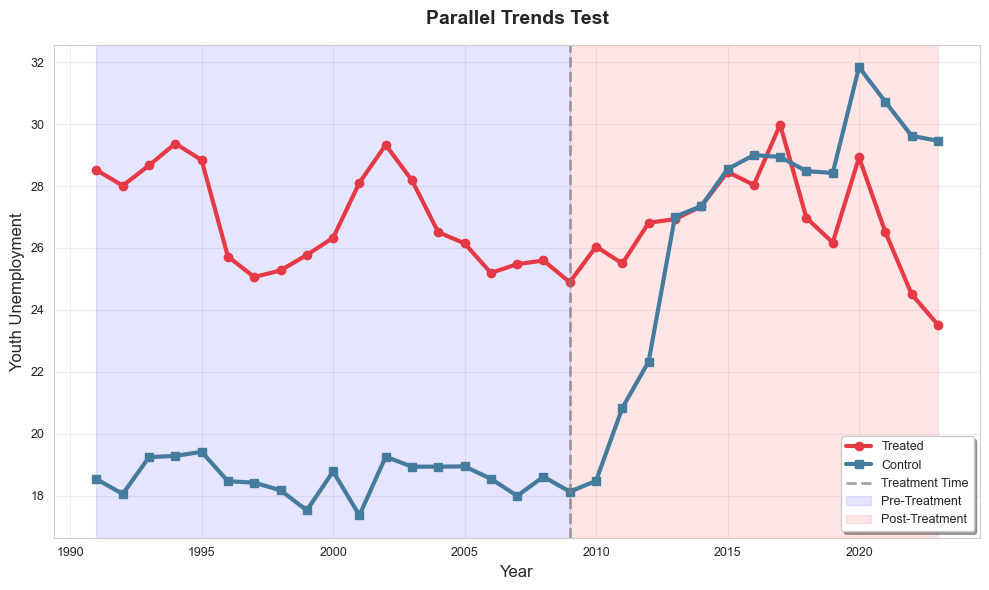

In [2]:
# Test parallel trends in pre-period
did = DifferenceInDifferences(df, 'youth_unemployment')
parallel_test = did.parallel_trends_test(pre_periods=3)

print("Parallel Trends Test (Pre-Treatment Years):")
display(parallel_test)

if parallel_test['Significant'].sum() == 0:
    print("\n✓ PASS: No significant pre-trends. Parallel trends assumption holds.")
else:
    print("\n⚠ WARNING: Significant pre-trends detected. DiD may be biased.")

# Visualize
treatment_time = df[df['post'] == 1]['year'].min()
plot_parallel_trends(df, 'year', 'youth_unemployment', 'treated', treatment_time,
                    save_path='../results/figures/05_parallel_trends.png')


## Test 2: Placebo Test

A placebo test assigns a fictitious treatment year and re-estimates the DiD model. Under a valid identification strategy, the placebo interaction term should be statistically indistinguishable from zero.


In [3]:
# Placebo test: use fake treatment year in pre-period
pre_data = df[df['year'] < treatment_time]
fake_years = [1995, 2000, 2003]

placebo_results = []
for fake_year in fake_years:
    result = placebo_test(pre_data, 'youth_unemployment', 'treated', 'post', fake_year)
    placebo_results.append(result)

placebo_df = pd.DataFrame(placebo_results)
print("\nPlacebo Test Results:")
display(placebo_df)

if placebo_df['Pass Test'].sum() == len(placebo_df):
    print("\n✓ PASS: No significant placebo effects. Results are robust.")
else:
    print("\n⚠ WARNING: Significant placebo effects detected.")



Placebo Test Results:


,Fake Treatment Year,Placebo Effect,p-value,Significant,Pass Test
0,1995,-1.890829,0.637617,False,True
1,2000,-0.283270,0.925336,False,True
2,2003,-1.195915,0.695908,False,True



✓ PASS: No significant placebo effects. Results are robust.


## Robustness Summary

**Parallel trends:** No statistically significant pre-treatment divergence detected between treated and control groups.

**Placebo tests:** Falsified treatment timing produces no significant effects, consistent with the absence of spurious confounding.

The causal estimates from Notebook 4 are robust to these specification checks.

**Limitations:** Results should be interpreted with awareness of potential spillovers between neighboring economies, measurement error in enrollment rates for earlier years, and the possibility of time-varying unobserved confounders not captured by country and year fixed effects.
